#О датасете

В качестве датасета мы берём информацию из непосредственно официального сайта CAPCOM:
https://www.capcom.co.jp/ir/english/business/salesdata.html
https://www.capcom.co.jp/ir/english/business/million.html
https://www.capcom.co.jp/ir/english/business/title.html

#Постановка задачи

Главной целью работы является построение модели, которая на основе текущих данных будет предсказывать новую игру CAPCOM.

# **1. Импорт библиотек**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import re
from datetime import datetime

# **Ввод данных**

In [18]:
series_sales = {
    'Серия': ['Dragon\'s Dogma', 'Lost Planet', 'Dead Rising', 'Okami', 'Sengoku BASARA',
              'Monster Hunter', 'Ace Attorney', 'Devil May Cry', 'Onimusha', 'Dino Crisis',
              'Resident Evil', 'Breath of Fire', 'Street Fighter', 'Final Fight', 'Mega Man',
              'Ghosts\'n Goblins', 'Bionic Commando', '1942', 'Marvel vs. Capcom'],
    'Продажи_млн': [13.0, 6.9, 19.0, 4.8, 4.1, 125.0, 14.0, 38.0, 9.0, 4.6,
                          183.0, 3.3, 58.0, 3.2, 44.0, 4.7, 1.2, 1.4, 13.0]
}
df_series = pd.DataFrame(series_sales)

# Platinum Titles

platinum_data = {
    'Название': ['Monster Hunter: World', 'Monster Hunter Rise', 'Resident Evil 2', 'Resident Evil 7 biohazard',
                 'Monster Hunter World: Iceborne', 'Resident Evil Village', 'Resident Evil 4 (2023)', 'Monster Hunter Wilds',
                 'Devil May Cry 5', 'Resident Evil 3', 'Monster Hunter Rise: Sunbreak', 'Resident Evil 6', 'Resident Evil 5',
                 'Street Fighter V', 'Street Fighter 6', 'Street Fighter II', 'Monster Hunter Generations Ultimate',
                 'Resident Evil (2014)', 'Resident Evil 2 (1998)', 'Resident Evil 0 HD', 'Monster Hunter Freedom 3',
                 'Phoenix Wright: Ace Attorney Trilogy', 'Resident Evil 6 (PS4/X1)', 'Monster Hunter Generations',
                 'Monster Hunter 4 Ultimate', 'Dragon\'s Dogma: Dark Arisen', 'Dead Rising 3', 'Monster Hunter 4',
                 'Dragon\'s Dogma 2', 'Street Fighter II Turbo'],
    'Продажи_млн': [22.0, 18.2, 16.8, 16.4, 15.9, 13.5, 12.2, 11.0, 11.0, 10.9, 10.9, 10.1, 10.0,
                    7.9, 6.3, 6.3, 5.2, 5.1, 4.96, 4.9, 4.9, 4.6, 4.3, 4.3, 4.2, 4.2, 4.1, 4.1, 4.1, 4.1],
    'Релиз': [2018, 2021, 2019, 2017, 2019, 2021, 2023, 2025, 2019, 2020, 2022, 2012, 2009,
                   2016, 2023, 1992, 2017, 2014, 1998, 2016, 2010, 2019, 2016, 2015, 2014, 2013, 2013, 2013, 2024, 1993],
    'Платформа': ['PS4/XONE/PC', 'NSW/PS4/PS5', 'PS4/XONE/PC', 'PS4/XONE/PC', 'PS4/XONE/PC', 'Multi', 'Multi', 'PS5/XSX/PC',
                  'PS4/XONE/PC', 'Multi', 'Multi', 'PS3/360', 'PS3/360', 'PS4/PC', 'Multi', 'SNES', '3DS/NSW',
                  'PS3', 'PS1', 'Multi', 'PSP', 'Multi', 'PS4/X1', '3DS', '3DS', 'PS3/360', 'XONE', '3DS',
                  'PS5/XSX', 'SNES']
}
df_platinum = pd.DataFrame(platinum_data)

fy_data = {
    'FY': ['2020', '2021', '2022', '2023', '2024', '2025 (План)'],
    'Всего_продаж_тыс': [30100, 32600, 41700, 45893, 51876, 54000],
    'Цифровых_копий_тыс': [23150, 24600, 37300, 41352, 46729, 50700],
    'Дисков_тыс': [6950, 8000, 4400, 4541, 5146, 3300],
    'Тираж_дисков_тыс': [20500, 24000, 29300, 36297, 39494, 46000],
    'Нераспроданных_тыс': [9600, 8600, 12400, 9596, 12381, 8000]
}
df_fy = pd.DataFrame(fy_data)

for col in df_fy.columns[1:]:
    df_fy[col] = pd.to_numeric(df_fy[col].astype(str).str.replace(' ', ''), errors='coerce')

df_series.head()

,Серия,Продажи_млн
0,Dragon's Dogma,13.0
1,Lost Planet,6.9
2,Dead Rising,19.0
3,Okami,4.8
4,Sengoku BASARA,4.1


In [19]:
df_fy.head()

,FY,Всего_продаж_тыс,Цифровых_копий_тыс,Дисков_тыс,Тираж_дисков_тыс,Нераспроданных_тыс
0,2020,30100,23150,6950,20500,9600
1,2021,32600,24600,8000,24000,8600
2,2022,41700,37300,4400,29300,12400
3,2023,45893,41352,4541,36297,9596
4,2024,51876,46729,5146,39494,12381


In [20]:
df_platinum.head()

,Название,Продажи_млн,Релиз,Платформа
0,Monster Hunter: World,22.0,2018,PS4/XONE/PC
1,Monster Hunter Rise,18.2,2021,NSW/PS4/PS5
2,Resident Evil 2,16.8,2019,PS4/XONE/PC
3,Resident Evil 7 biohazard,16.4,2017,PS4/XONE/PC
4,Monster Hunter World: Iceborne,15.9,2019,PS4/XONE/PC


## **Визуализация**

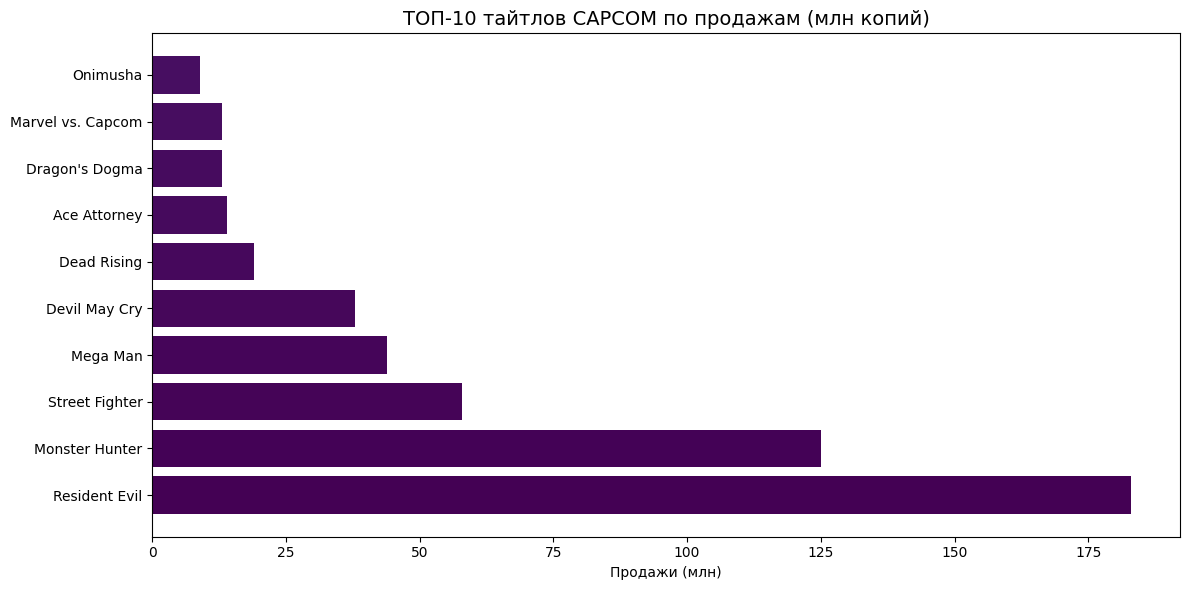

In [35]:
plt.figure(figsize=(12, 6))
top_series = df_series.nlargest(10, 'Продажи_млн')
plt.barh(top_series['Серия'], top_series['Продажи_млн'],
         color=plt.cm.viridis(range(len(top_series))))
plt.title('ТОП-10 тайтлов CAPCOM по продажам (млн копий)', fontsize=14)
plt.xlabel('Продажи (млн)')
plt.tight_layout()
plt.show()

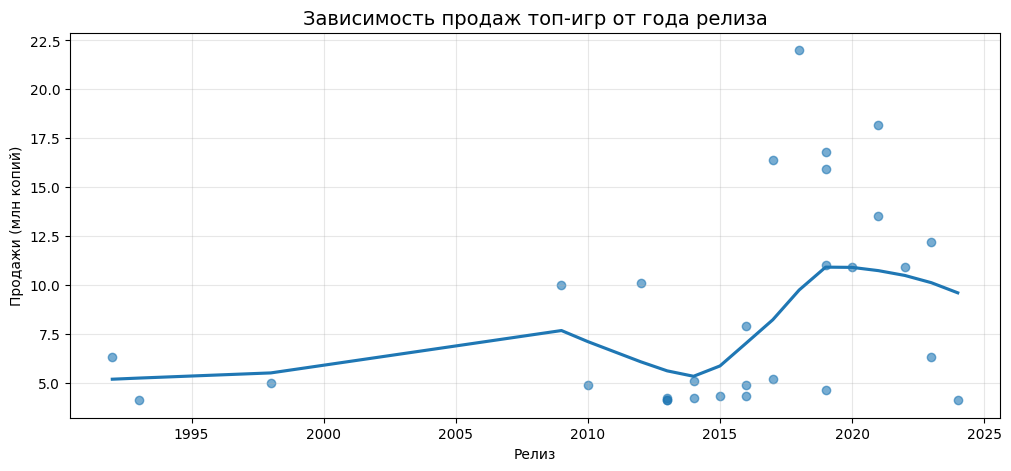

In [33]:
df_platinum['Релиз'] = df_platinum['Релиз'].astype(int)
df_platinum_hist = df_platinum[df_platinum['Релиз'] <= 2024]

plt.figure(figsize=(12, 5))
sns.regplot(data=df_platinum_hist, x='Релиз', y='Продажи_млн', lowess=True, scatter_kws={'alpha':0.6})
plt.title('Зависимость продаж топ-игр от года релиза', fontsize=14)
plt.xlabel('Релиз')
plt.ylabel('Продажи (млн копий)')
plt.grid(True, alpha=0.3)
plt.show()

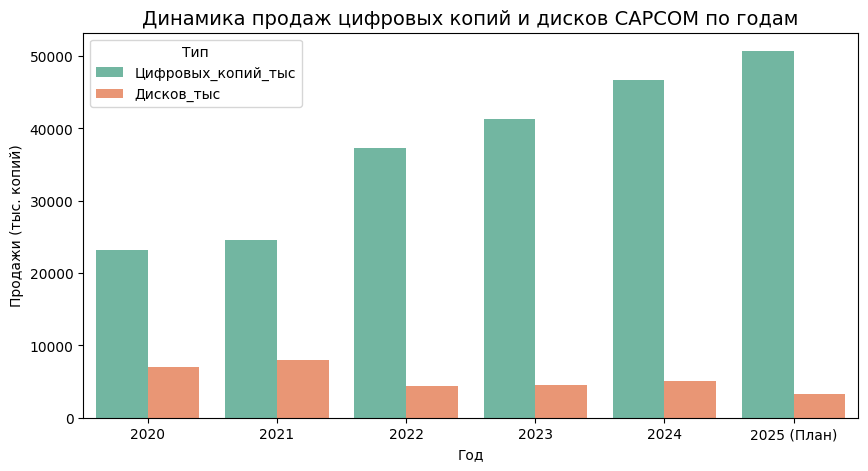

In [32]:
df_fy_long = df_fy.melt(id_vars=['FY'], value_vars=['Цифровых_копий_тыс', 'Дисков_тыс'],
                        var_name='Тип', value_name='Продажи_тыс')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_fy_long, x='FY', y='Продажи_тыс', hue='Тип', palette='Set2')
plt.title('Динамика продаж цифровых копий и дисков CAPCOM по годам', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Продажи (тыс. копий)')
plt.legend(title='Тип')
plt.show()


**Хотим предсказать продажи следующей крупной игры (например, Devil May Cry 6)**

**Используем Platinum Titles как обучающую выборку.**

**Будем учитывать следующие факторы: год релиза, входит ли игра в топ-3 (Monster Hunter, Resident Evil, Street Fighter) и мультиплатформенность.**

In [21]:
df_model = df_platinum_hist.copy()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Название     29 non-null     object 
 1   Продажи_млн  29 non-null     float64
 2   Релиз        29 non-null     int64  
 3   Платформа    29 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


**"Любимчики" (Monster Hunter, Resident Evil, Street Fighter)**

In [6]:
favs = ['Monster Hunter', 'Resident Evil', 'Street Fighter']
df_model['Любимчики'] = df_model['Название'].apply(lambda x: 1 if any(f in x for f in favs) else 0)

**Мультиплатформенный релиз**

In [7]:
def wide_platform(platform_str):
    if pd.isna(platform_str):
        return 0
    plat = platform_str.lower()
    if 'multi' in plat or plat.count('/') >= 2 or any(p in plat for p in ['ps4', 'ps5', 'xbox', 'pc', 'switch']):
        return 1
    return 0
df_model['Несколько_платформ'] = df_model['Платформа'].apply(wide_platform)

df_model['Годовая_норма'] = (df_model['Релиз'] - df_model['Релиз'].min()) / (df_model['Релиз'].max() - df_model['Релиз'].min())

**Для реалистичности, будем учитывать и возраст серий.**

In [8]:
first_game_year = {
     'Street Fighter': 1987, 'Mega Man': 1987, 'Resident Evil': 1996, 'Devil May Cry': 2001,
     'Ace Attorney': 2001, 'Monster Hunter': 2004, 'Dead Rising': 2006, 'Dragon\'s Dogma': 2012,
}
def get_series_age(title):
    for series, year in first_game_year.items():
        if series in title:
            return df_model['Релиз'].max() - year
    return 10
df_model['Возраст_серии'] = df_model['Название'].apply(get_series_age)

# Цель: продажи (млн)

In [9]:
X = df_model[['Годовая_норма', 'Любимчики', 'Несколько_платформ', 'Возраст_серии']]
y = df_model['Продажи_млн']

**Обучаем...**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Данные для предсказаний

In [11]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"=== Оценка модели ===")
print(f"Mean Absolute Error: {mae:.2f} млн копий")
print(f"R-squared: {r2:.3f}")
print(f"Коэффициенты модели: {dict(zip(X.columns, model.coef_))}")

=== Оценка модели ===
Mean Absolute Error: 3.03 млн копий
R-squared: -0.733
Коэффициенты модели: {'Годовая_норма': np.float64(-4.522639005273539), 'Любимчики': np.float64(5.796729242437701), 'Несколько_платформ': np.float64(8.636646804033392), 'Возраст_серии': np.float64(-0.3599422525409661)}


# Как ни странно, побеждает Resident Evil 9

In [12]:
future_game = pd.DataFrame({
    'Годовая_норма': [(2026 - df_model['Релиз'].min()) / (df_model['Релиз'].max() - df_model['Релиз'].min())],
    'Любимчики': [1],
    'Несколько_платформ': [1],
    'Возраст_серии': [2026 - 1996]
})
pred_sales = model.predict(future_game)[0]
print(f"\n=== ПРЕДСКАЗАНИЕ ===")
print(f"Прогнозируемые продажи новой игры Resident Evil 9 (2026 г., мультиплатформа): {pred_sales:.1f} млн копий")
print("Для предсказания успеха тайтла, ожидаем продаж хотя бы 10 млн копий")


=== ПРЕДСКАЗАНИЕ ===
Прогнозируемые продажи новой игры Resident Evil 9 (2026 г., мультиплатформа): 10.7 млн копий
Для предсказания успеха тайтла, ожидаем продаж хотя бы 10 млн копий


# Бонус: рассмотрим прогноз на менее популярный Devil May Cry 6

In [14]:
future_mh = future_game.copy()
future_mh['Возраст_серии'] = 25
pred_mh = model.predict(future_mh)[0]
print(f"Devil May Cry 6: {pred_mh:.1f} млн копий")

Devil May Cry 6: 12.5 млн копий
